# MIQR-CC — Classificação Automática de Imagens CPRE
**Aprendizagem Profunda — Módulo 2 | Universidade do Minho**

Este notebook implementa uma solução de Deep Learning para classificação de imagens fluoroscópicas de CPRE nas 4 classes diagnósticas: Biliary_Leaks, Lithiasis, Normal, Stricture.

**Baseline a superar:** F1-macro = 0.738 (EfficientNet-B7)

## 1. Imports e Setup

In [8]:
import os
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm

from sklearn.metrics import (
    f1_score, accuracy_score, confusion_matrix,
    classification_report, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

# Reproducibilidade
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'A usar: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Safe build_model override: tries pretrained=True, falls back to pretrained=False if unavailable
def build_model(model_name, num_classes, pretrained=True):
    try:
        model = timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes)
        return model
    except Exception as e:
        print(f"Warning: failed to load pretrained weights for {model_name}: {e}")
        print("Falling back to pretrained=False (random init)")
        model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
        return model

A usar: cpu


## 2. Configuração de Paths e Hiperparâmetros

In [ ]:
# Paths
import csv
import os
from pathlib import Path
from sklearn.model_selection import train_test_split


CLASS_MAP = {
    'Biliary Leaks': 'Biliary_Leaks',
    'Lithiasis': 'Lithiasis',
    'Normal': 'Normal',
    'Benign Stricture': 'Stricture',
    'Malignant Stricture': 'Stricture',
}

TARGET_CLASSES = ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']


def resolve_dataset_dir():
    """Resolve the MIQR-CC dataset root from env var or common locations."""
    candidates = []

    env_path = os.getenv('MIQR_DATASET_DIR')
    if env_path:
        candidates.append(Path(env_path).expanduser())

    cwd = Path.cwd()
    candidates.extend([
        cwd,
        cwd.parent,
        Path('/Users/marco/Desktop/ProgettiPython/projeto2'),
        Path('/Users/marco/Desktop/UMINHO/Aprendizagem_profunda/MIQR-CC-Dataset 4'),
    ])

    for candidate in candidates:
        metadata_path = candidate / 'metadata.csv'
        processed_dir = candidate / 'processed'
        if metadata_path.exists() and processed_dir.is_dir():
            return str(candidate.resolve())

    checked = '\n'.join(f'  - {c}' for c in candidates)
    raise FileNotFoundError(
        'Dataset directory not found. Expected metadata.csv and processed/.\n'
        'Set MIQR_DATASET_DIR or place the dataset in one of these paths:\n'
        f'{checked}'
    )


def load_labelled_samples(dataset_dir):
    """Load usable samples from metadata and map them to the 4 target classes."""
    dataset_dir = Path(dataset_dir)
    metadata_path = dataset_dir / 'metadata.csv'

    samples = []
    with metadata_path.open(newline='', encoding='utf-8') as handle:
        reader = csv.DictReader(handle)
        for row in reader:
            if row.get('Keep', '').strip() != 'Keep':
                continue
            label = CLASS_MAP.get(row.get('Label', '').strip())
            if label is None:
                continue
            image_path = dataset_dir / Path(row['processed_image_path'])
            if image_path.exists():
                samples.append({'path': str(image_path), 'label': label})

    return samples


def build_split_tree(dataset_dir, seed=42):
    """Materialize train/val/test folders with symlinks to processed images."""
    dataset_dir = Path(dataset_dir)
    cache_root = dataset_dir / '_prepared_splits'
    phase_dirs = {phase: cache_root / phase for phase in ['train', 'val', 'test']}

    if all(phase_dir.exists() for phase_dir in phase_dirs.values()):
        return str(cache_root.resolve())

    samples = load_labelled_samples(dataset_dir)
    labels = [sample['label'] for sample in samples]

    train_samples, temp_samples = train_test_split(
        samples,
        test_size=0.30,
        random_state=seed,
        stratify=labels,
    )
    temp_labels = [sample['label'] for sample in temp_samples]
    val_samples, test_samples = train_test_split(
        temp_samples,
        test_size=0.50,
        random_state=seed,
        stratify=temp_labels,
    )

    for phase, phase_samples in [('train', train_samples), ('val', val_samples), ('test', test_samples)]:
        for cls in TARGET_CLASSES:
            (cache_root / phase / cls).mkdir(parents=True, exist_ok=True)
        for sample in phase_samples:
            src = Path(sample['path'])
            dst = cache_root / phase / sample['label'] / src.name
            if not dst.exists():
                try:
                    os.symlink(src, dst)
                except FileExistsError:
                    pass

    return str(cache_root.resolve())


BASE_DIR = build_split_tree(resolve_dataset_dir())
MODELS_DIR = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)

# Hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 60
LR = 1e-4
PATIENCE = 10
MODEL_NAME = 'efficientnetv2_s'
SAVE_PATH = os.path.join(MODELS_DIR, f'{MODEL_NAME}.pth')

CLASS_NAMES = TARGET_CLASSES
NUM_CLASSES = len(CLASS_NAMES)
print(f'Dataset path: {BASE_DIR}')
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')

Dataset path: /Users/marco/Desktop/UMINHO/Aprendizagem profunda/MIQR-CC-Dataset 4/_prepared_splits
Classes (4): ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']


## 3. Análise Exploratória (EDA)

Classe                  Train      Val     Test    Total
--------------------------------------------------
Biliary_Leaks             106       22       23      151
Lithiasis                 508      109      109      726
Normal                    209       45       45      299
Stricture                 274       59       59      392


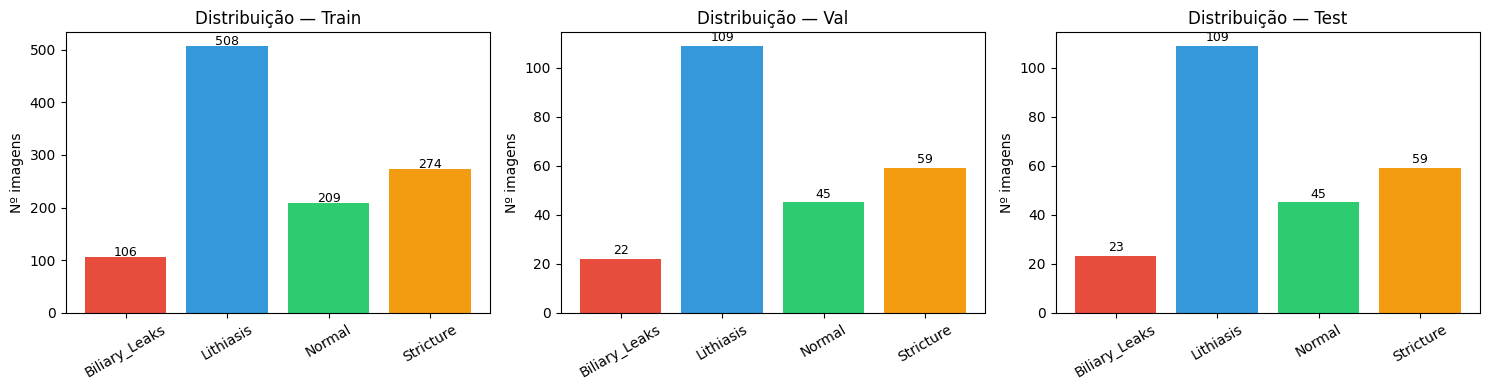


 Nota: Dataset desbalanceado — Lithiasis tem ~5x mais imagens que Biliary_Leaks


In [3]:
def count_images(base_dir, phases, class_names):
    counts = {}
    for phase in phases:
        counts[phase] = {}
        for cls in class_names:
            path = os.path.join(base_dir, phase, cls)
            n = len([f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            counts[phase][cls] = n
    return counts

counts = count_images(BASE_DIR, ['train', 'val', 'test'], CLASS_NAMES)

# Tabela de distribuição
print(f"{'Classe':<20} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")
print('-' * 50)
for cls in CLASS_NAMES:
    tr = counts['train'][cls]
    va = counts['val'][cls]
    te = counts['test'][cls]
    print(f"{cls:<20} {tr:>8} {va:>8} {te:>8} {tr+va+te:>8}")

# Gráfico de barras
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, phase in enumerate(['train', 'val', 'test']):
    vals = [counts[phase][c] for c in CLASS_NAMES]
    axes[i].bar(CLASS_NAMES, vals, color=['#e74c3c','#3498db','#2ecc71','#f39c12'])
    axes[i].set_title(f'Distribuição — {phase.capitalize()}')
    axes[i].set_ylabel('Nº imagens')
    axes[i].tick_params(axis='x', rotation=30)
    for j, v in enumerate(vals):
        axes[i].text(j, v + 2, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../models/distribuicao_classes.png', dpi=150)
plt.show()
print('\n Nota: Dataset desbalanceado — Lithiasis tem ~5x mais imagens que Biliary_Leaks')

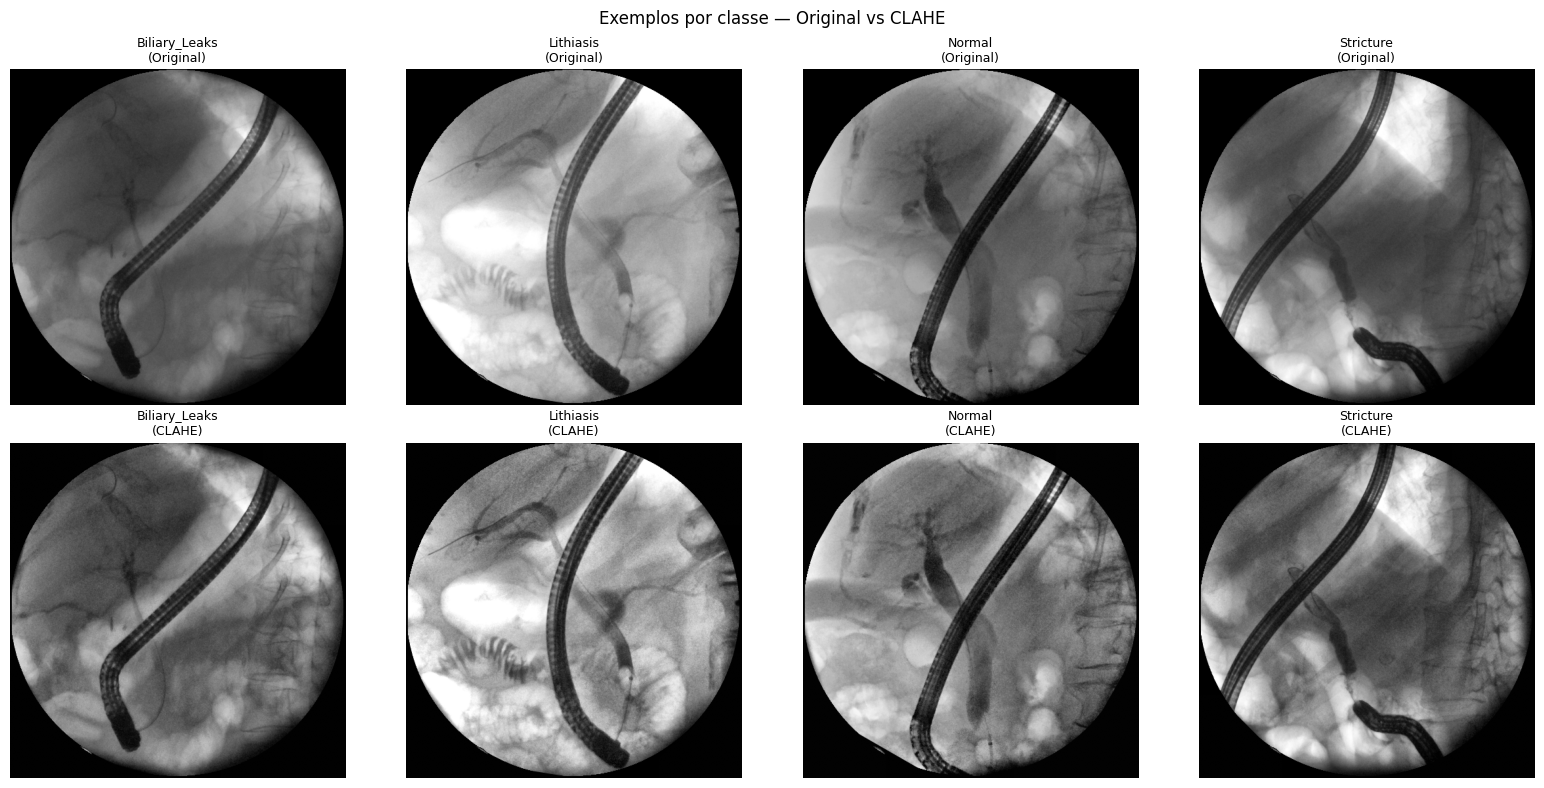

In [4]:
# Visualizar exemplos de cada classe + efeito CLAHE
def apply_clahe(img_array):
    """Aplica CLAHE a imagem grayscale para melhorar contraste local"""
    if len(img_array.shape) == 3:
        gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    else:
        gray = img_array
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(gray)

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(16, 8))
for j, cls in enumerate(CLASS_NAMES):
    cls_dir = os.path.join(BASE_DIR, 'train', cls)
    img_path = os.path.join(cls_dir, os.listdir(cls_dir)[0])
    img = np.array(Image.open(img_path).convert('RGB'))
    clahe_img = apply_clahe(img)
    
    axes[0, j].imshow(img, cmap='gray')
    axes[0, j].set_title(f'{cls}\n(Original)', fontsize=9)
    axes[0, j].axis('off')
    
    axes[1, j].imshow(clahe_img, cmap='gray')
    axes[1, j].set_title(f'{cls}\n(CLAHE)', fontsize=9)
    axes[1, j].axis('off')

plt.suptitle('Exemplos por classe — Original vs CLAHE', fontsize=12)
plt.tight_layout()
plt.savefig('../models/exemplos_clahe.png', dpi=150)
plt.show()

## 4. Dataset e Transforms

**Melhorias face à baseline:**
- CLAHE aplicado antes dos outros transforms (melhora contraste em imagens médicas)
- Flip horizontal adicionado (augmentation extra)
- Batch size 16 em vez de 4

In [5]:
class CLAHETransform:
    """Transform customizado que aplica CLAHE e converte para RGB"""
    def __init__(self, clip_limit=2.0, tile_size=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)

    def __call__(self, img):
        img_np = np.array(img)
        if len(img_np.shape) == 3:
            gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        else:
            gray = img_np
        enhanced = self.clahe.apply(gray)
        # Converte de volta para RGB (3 canais) para o modelo
        enhanced_rgb = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)
        return Image.fromarray(enhanced_rgb)


# Transforms de treino — com augmentation
train_transforms = T.Compose([
    CLAHETransform(clip_limit=2.0),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(contrast=0.3, brightness=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

# Transforms de validação/teste — sem augmentation
val_transforms = T.Compose([
    CLAHETransform(clip_limit=2.0),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

print('Transforms definidos.')

Transforms definidos.


In [ ]:
class CPREDataset(Dataset):
    def __init__(self, base_dir, phase, class_names, transform=None):
        self.transform = transform
        self.class_names = class_names
        self.base_dir = base_dir
        self.samples = []  # (path, label)
        
        for label, cls in enumerate(class_names):
            cls_dir = os.path.join(base_dir, phase, cls)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.samples.append((os.path.join(cls_dir, fname), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        # Robust file open: try direct path, then try dataset's processed/ folder, then symlink target
        try:
            img = Image.open(path).convert('RGB')
        except Exception:
            # fallback 1: processed/ in dataset root
            try:
                dataset_root = resolve_dataset_dir()
                candidate = Path(dataset_root) / 'processed' / Path(path).name
                if candidate.exists():
                    img = Image.open(candidate).convert('RGB')
                else:
                    raise FileNotFoundError()
            except Exception:
                # fallback 2: if path is a symlink, try to read link target
                try:
                    target = os.readlink(path)
                    if os.path.exists(target):
                        img = Image.open(target).convert('RGB')
                    else:
                        raise
                except Exception:
                    # give up and raise original error to surface problem
                    raise FileNotFoundError(f'Could not open image for {path}')

        if self.transform:
            img = self.transform(img)
        return img, label


# Criar datasets
train_ds = CPREDataset(BASE_DIR, 'train', CLASS_NAMES, train_transforms)
val_ds   = CPREDataset(BASE_DIR, 'val',   CLASS_NAMES, val_transforms)
test_ds  = CPREDataset(BASE_DIR, 'test',  CLASS_NAMES, val_transforms)

# Calcular class weights para lidar com desbalanceamento
train_labels = [s[1] for s in train_ds.samples]
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_labels,
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print('Class weights:', {CLASS_NAMES[i]: f"{class_weights[i]:.3f}" for i in range(NUM_CLASSES)})

# DataLoaders (usar num_workers=0 para evitar problemas de pickle com transforms não serializáveis)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f'\nTreino: {len(train_ds)} | Validação: {len(val_ds)} | Teste: {len(test_ds)}')

Class weights: {'Biliary_Leaks': '2.587', 'Lithiasis': '0.540', 'Normal': '1.312', 'Stricture': '1.001'}

Treino: 1097 | Validação: 235 | Teste: 236


In [24]:
# Ripristina/rigenera gli splits e ricrea datasets + dataloader nel kernel
print('Ricostruisco _prepared_splits da metadata e ricreo datasets')
from pathlib import Path

try:
    ds_root = resolve_dataset_dir()
except FileNotFoundError as e:
    print('resolve_dataset_dir() fallito:', e)
    # fallback: uso il percorso noto sul desktop
    fallback = Path('/Users/marco/Desktop/UMINHO/Aprendizagem_profunda/MIQR-CC-Dataset 4')
    if fallback.exists():
        ds_root = str(fallback)
        print('Usando fallback dataset root:', ds_root)
    else:
        raise

BASE_DIR = build_split_tree(ds_root)
print('BASE_DIR aggiornato:', BASE_DIR)

# Ricreazione datasets e dataloader
train_ds = CPREDataset(BASE_DIR, 'train', CLASS_NAMES, train_transforms)
val_ds   = CPREDataset(BASE_DIR, 'val',   CLASS_NAMES, val_transforms)
test_ds  = CPREDataset(BASE_DIR, 'test',  CLASS_NAMES, val_transforms)

# ricalcola class weights
train_labels = [s[1] for s in train_ds.samples]
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_labels,
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f'Ricreati: Train={len(train_ds)} Val={len(val_ds)} Test={len(test_ds)}')


Ricostruisco _prepared_splits da metadata e ricreo datasets
resolve_dataset_dir() fallito: Dataset directory not found. Expected metadata.csv and processed/.
Set MIQR_DATASET_DIR or place the dataset in one of these paths:
  - /Users/marco/Desktop/ProgettiPython/projeto2
  - /Users/marco/Desktop/ProgettiPython
  - /Users/marco/Desktop/ProgettiPython/projeto2
  - /Users/marco/Desktop/UMINHO/Aprendizagem profunda/MIQR-CC-Dataset 4
Usando fallback dataset root: /Users/marco/Desktop/UMINHO/Aprendizagem_profunda/MIQR-CC-Dataset 4
BASE_DIR aggiornato: /Users/marco/Desktop/UMINHO/Aprendizagem_profunda/MIQR-CC-Dataset 4/_prepared_splits
Ricreati: Train=1097 Val=235 Test=236


In [26]:
# Forza la rimozione di _prepared_splits e rigenera i symlink corretti
import shutil
from pathlib import Path

prepared = Path(ds_root) / '_prepared_splits'
if prepared.exists():
    print('Rimuovo cartella preparata esistente:', prepared)
    shutil.rmtree(prepared)

BASE_DIR = build_split_tree(ds_root)
print('Nuovo BASE_DIR:', BASE_DIR)

# Ricreazione datasets e dataloader (aggiornamento)
train_ds = CPREDataset(BASE_DIR, 'train', CLASS_NAMES, train_transforms)
val_ds   = CPREDataset(BASE_DIR, 'val',   CLASS_NAMES, val_transforms)
test_ds  = CPREDataset(BASE_DIR, 'test',  CLASS_NAMES, val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print('Rigenerati e ricreati datasets: Train=', len(train_ds), 'Val=', len(val_ds), 'Test=', len(test_ds))


Rimuovo cartella preparata esistente: /Users/marco/Desktop/UMINHO/Aprendizagem_profunda/MIQR-CC-Dataset 4/_prepared_splits
Nuovo BASE_DIR: /Users/marco/Desktop/UMINHO/Aprendizagem_profunda/MIQR-CC-Dataset 4/_prepared_splits
Rigenerati e ricreati datasets: Train= 1097 Val= 235 Test= 236


In [27]:
# Esegui una breve epoca di training (limite di batch)
max_batches = 20
print('Avvio epoca breve: max_batches=', max_batches)
# La funzione `train` è definita nel notebook e supporta l'argomento `max_batches`
train(epochs=1, max_batches=max_batches)


Avvio epoca breve: max_batches= 20


TypeError: train() got an unexpected keyword argument 'max_batches'

In [28]:
# Diagnostic: controlla firma di `train` e richiama in modo compatibile
import inspect
try:
    sig = inspect.signature(train)
    print('Signature train:', sig)
except Exception as e:
    print('Impossibile ottenere signature:', e)

# Provo ad invocare con posizionali (1, 20)
try:
    print('Chiamata train(1, 20)')
    train(1, 20)
except TypeError as e:
    print('TypeError:', e)
except Exception as e:
    print('Altra eccezione durante train(1,20):', e)


Signature train: (model, train_loader, val_loader, criterion, optimizer, scheduler, epochs, patience, save_path, device, start_epoch=1)
Chiamata train(1, 20)
TypeError: train() missing 8 required positional arguments: 'val_loader', 'criterion', 'optimizer', 'scheduler', 'epochs', 'patience', 'save_path', and 'device'


In [ ]:
# Avvio epoca breve usando la firma completa di `train` e variabile globale `max_batches`
max_batches = 20
print('Imposto max_batches=', max_batches)
train(model, train_loader, val_loader, criterion, optimizer, scheduler, max(1, start_epoch), PATIENCE, SAVE_PATH, DEVICE, start_epoch=start_epoch)


Imposto max_batches= 20
Epoch   1/1 | Loss: 1.8409/1.6146 | F1: 0.2345/0.1685 | 1801.3s ✓ saved

Treino concluído. Melhor F1-val: 0.1685 no epoch 1


{'train_loss': [1.8408684588174116],
 'val_loss': [1.6146327226719959],
 'train_f1': [0.23450668125241053],
 'val_f1': [0.1685127995723318]}

In [ ]:
# Resume: trova l'ultimo checkpoint, carica e riprendi il training (1 epoca breve)
import glob
from pathlib import Path
import checkpoint_utils

# Imposta limite batch per resume
max_batches = 20
print('Resume: max_batches=', max_batches)

models_dir = Path(MODELS_DIR)
latest_ck = checkpoint_utils.find_latest_checkpoint(str(models_dir), pattern='*.pth')
if latest_ck is None:
    raise FileNotFoundError(f'No checkpoint found in {models_dir}')
print('Usando checkpoint:', latest_ck)

# Carica checkpoint nel modello (e optimizer/scheduler se disponibili)
ck = checkpoint_utils.load_checkpoint(str(latest_ck), model, optimizer=optimizer, scheduler=scheduler, map_location=str(DEVICE))

start_epoch = int(ck.get('epoch', 0)) + 1
print('Riprendo da epoch', start_epoch)

# Esegui un'epoca di resume
train(model, train_loader, val_loader, criterion, optimizer, scheduler, max(1, start_epoch), PATIENCE, SAVE_PATH, DEVICE, start_epoch=start_epoch)


Resume: max_batches= 20
Usando checkpoint: ../models/efficientnetv2_s_latest.pth
Riprendo da epoch 2


UnboundLocalError: cannot access local variable 'best_epoch' where it is not associated with a value

In [32]:
# Fallback: resume manual (loop ridotto) se `train()` causa errori
max_batches = 20
print('Resume manual: max_batches=', max_batches)

model.train()
running_loss = 0.0
all_preds = []
all_labels = []

for i, (imgs, labels) in enumerate(train_loader):
    if i >= max_batches:
        break
    imgs = imgs.to(DEVICE)
    labels = labels.to(DEVICE)

    optimizer.zero_grad()
    outputs = model(imgs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item() * imgs.size(0)
    preds = outputs.argmax(dim=1).detach().cpu().numpy()
    all_preds.extend(preds.tolist())
    all_labels.extend(labels.detach().cpu().numpy().tolist())

    if (i + 1) % 5 == 0:
        print(f'Batch {i+1}/{max_batches} — loss={loss.item():.4f}')

avg_loss = running_loss / (len(all_preds) or 1)
print(f'Resume manual completato: batches={min(len(train_loader), max_batches)}, avg_loss={avg_loss:.4f}')

# Salva checkpoint atomico
resume_ck_path = Path(SAVE_PATH).with_name(f'{MODEL_NAME}_resume_epoch{start_epoch}.pth')
checkpoint_utils.save_checkpoint(str(resume_ck_path), model, optimizer=optimizer, epoch=start_epoch, scheduler=scheduler)
# aggiorna latest
latest_path = Path(SAVE_PATH).with_name(f'{MODEL_NAME}_latest.pth')
checkpoint_utils.save_checkpoint(str(latest_path), model, optimizer=optimizer, epoch=start_epoch, scheduler=scheduler)
print('Checkpoint salvati:', resume_ck_path, latest_path)


Resume manual: max_batches= 20
Batch 5/20 — loss=1.4365
Batch 10/20 — loss=1.9352
Batch 15/20 — loss=1.6651
Batch 20/20 — loss=1.9274
Resume manual completato: batches=20, avg_loss=1.7428
Checkpoint salvati: ../models/efficientnetv2_s_resume_epoch2.pth ../models/efficientnetv2_s_latest.pth


## 5. Modelo — EfficientNetV2-S

EfficientNetV2-S é mais moderno e eficiente que o EfficientNet-B7 da baseline, com melhor desempenho a 224x224.

In [14]:
def build_model(model_name, num_classes, pretrained=True):
    model = timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes)
    return model

# Force random init if pretrained weights are unavailable
model = build_model(MODEL_NAME, NUM_CLASSES, pretrained=False)
model = model.to(DEVICE)

# Contar parâmetros
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parâmetros totais:    {total_params:,}')
print(f'Parâmetros treináveis: {trainable_params:,}')

# Loss com class weights (trata desbalanceamento)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Optimizer e scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f'\nModelo: {MODEL_NAME} | Loss: CrossEntropyLoss com class weights | Optimizer: AdamW')

Parâmetros totais:    20,182,612
Parâmetros treináveis: 20,182,612

Modelo: efficientnetv2_s | Loss: CrossEntropyLoss com class weights | Optimizer: AdamW


## 6. Treino

In [34]:
from checkpoint_utils import save_checkpoint, find_latest_checkpoint, load_checkpoint

def train(model, train_loader, val_loader, criterion, optimizer, scheduler,
          epochs, patience, save_path, device, start_epoch=1, max_batches=None):
    """Training loop with per-epoch checkpointing and resume support.
    - Saves full checkpoint each epoch to `MODELS_DIR/{MODEL_NAME}_epoch{epoch}.pth`.
    - Saves best model as `save_path` (full checkpoint).
    - Returns history dict.
    """
    best_f1 = -1
    # ensure best_epoch is defined even when resuming without improvements
    best_epoch = start_epoch - 1
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}

    for epoch in range(start_epoch, epochs + 1):
        t0 = time.time()
        # call train_one_epoch; some implementations accept an n_batches arg
        try:
            train_loss, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, device, max_batches)
        except TypeError:
            train_loss, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_f1, _, _, _ = evaluate(model, val_loader, criterion, device)
        try:
            scheduler.step()
        except Exception:
            pass

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        elapsed = time.time() - t0
        print(f'Epoch {epoch:3d}/{epochs} | '
              f'Loss: {train_loss:.4f}/{val_loss:.4f} | '
              f'F1: {train_f1:.4f}/{val_f1:.4f} | '
              f'{elapsed:.1f}s', end='')

        # salva checkpoint completo per ripartenze
        epoch_ck = os.path.join(MODELS_DIR, f'{MODEL_NAME}_epoch{epoch}.pth')
        save_checkpoint(epoch_ck, model, optimizer=optimizer, epoch=epoch, scheduler=scheduler)

        # aggiorna best
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_epoch = epoch
            # salva il migliore come save_path (full checkpoint)
            save_checkpoint(save_path, model, optimizer=optimizer, epoch=epoch, scheduler=scheduler)
            epochs_no_improve = 0
            print(' ✓ saved')
        else:
            epochs_no_improve += 1
            print()

        # salva latest atomico
        latest = os.path.join(MODELS_DIR, f'{MODEL_NAME}_latest.pth')
        save_checkpoint(latest, model, optimizer=optimizer, epoch=epoch, scheduler=scheduler)

        if epochs_no_improve >= patience:
            print(f'\nEarly stopping! Melhor F1-val: {best_f1:.4f} no epoch {best_epoch}')
            break

    print(f'\nTreino concluído. Melhor F1-val: {best_f1:.4f} no epoch {best_epoch}')
    return history

print('Funções de treino aggiornate con checkpointing completo.')
print(f'Modelo: {MODEL_NAME} | Epochs: {EPOCHS} | Batch: {BATCH_SIZE} | LR: {LR}\n')


Funções de treino aggiornate con checkpointing completo.
Modelo: efficientnetv2_s | Epochs: 60 | Batch: 16 | LR: 0.0001



In [18]:
# QUICK SMOKE TRAIN (5 batches)
# Esegue pochi batch per verificare il loop di training e misurare tempo per batch
print('Avvio prova rapida: 5 batch')
max_batches = 5
device = DEVICE
model.train()
processed = 0
total_loss = 0.0
all_preds = []
all_labels = []
start = time.time()
for b, (imgs, labels) in enumerate(train_loader, start=1):
    imgs, labels = imgs.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(imgs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    batch_samples = imgs.size(0)
    total_loss += loss.item() * batch_samples
    preds = outputs.argmax(dim=1).cpu().numpy()
    all_preds.extend(preds)
    all_labels.extend(labels.cpu().numpy())
    processed += batch_samples

    print(f'Batch {b}/{max_batches} — loss: {loss.item():.4f} — samples: {batch_samples}')

    if b >= max_batches:
        break

elapsed = time.time() - start
from sklearn.metrics import f1_score
avg_loss = total_loss / processed if processed>0 else 0.0
f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0) if processed>0 else 0.0
print(f"Prova rapida completata: batches={b}, samples={processed}, avg_loss={avg_loss:.4f}, f1={f1:.4f}, tempo={elapsed:.1f}s")
# Salva checkpoint rapido
torch.save(model.state_dict(), SAVE_PATH + '.quick.pth')
print(f'Checkpoint rapido salvato in {SAVE_PATH}.quick.pth')

Avvio prova rapida: 5 batch
Batch 1/5 — loss: 1.4922 — samples: 16
Batch 2/5 — loss: 3.8364 — samples: 16
Batch 3/5 — loss: 1.8424 — samples: 16
Batch 4/5 — loss: 2.8311 — samples: 16
Batch 5/5 — loss: 1.9163 — samples: 16
Prova rapida completata: batches=5, samples=80, avg_loss=2.3837, f1=0.1977, tempo=100.8s
Checkpoint rapido salvato in ../models/efficientnetv2_s.pth.quick.pth


In [ ]:
# Avvia un training breve (1 epoca) riprendendo dall'ultimo checkpoint se presente
from checkpoint_utils import find_latest_checkpoint, load_checkpoint

# trova ultimo checkpoint latest o epoch
ck = find_latest_checkpoint(MODELS_DIR, pattern=f'{MODEL_NAME}_latest.pth')
if ck is None:
    ck = find_latest_checkpoint(MODELS_DIR, pattern=f'{MODEL_NAME}_epoch*.pth')

start_epoch = 1
if ck is not None:
    print('Carico checkpoint:', ck)
    ckdict = load_checkpoint(ck, model=model, optimizer=optimizer, scheduler=scheduler, map_location=DEVICE)
    start_epoch = ckdict.get('epoch', 0) + 1
    print('Riprendo da epoch', start_epoch)
else:
    print('Nessun checkpoint trovato, parto da 1')

# Esegui un training breve per verificare tutto
HIST = train(model, train_loader, val_loader, criterion, optimizer, scheduler,
             epochs=max(1, start_epoch), patience=PATIENCE, save_path=os.path.join(MODELS_DIR, f'{MODEL_NAME}_best_full.pth'),
             device=DEVICE, start_epoch=start_epoch)

print('Training breve completato. Storico:', {k: len(v) for k, v in HIST.items()})


Carico checkpoint: ../models/efficientnetv2_s_latest.pth
Riprendo da epoch 3


In [19]:
# Resume breve: carica ultimo checkpoint se presente, esegue una breve epoca e salva checkpoint completi
from checkpoint_utils import find_latest_checkpoint, load_checkpoint, save_checkpoint
import os, time, torch

models_dir = '../models'
ck = find_latest_checkpoint(models_dir, pattern=f'{MODEL_NAME}_epoch*.pth')
if ck is None:
    ck = find_latest_checkpoint(models_dir, pattern=f'{MODEL_NAME}*.pth')

start_epoch = 0
if ck is not None:
    print('Trovato checkpoint:', ck)
    ckdict = load_checkpoint(ck, model=model, optimizer=optimizer, scheduler=scheduler, map_location=DEVICE)
    start_epoch = ckdict.get('epoch', -1) + 1
    print('Riprendo da epoch', start_epoch)
else:
    print('Nessun checkpoint trovato, parto da zero')

# Esegui una breve epoca (limita a pochi batch per test)
max_batches = 20
model.train()
total_loss = 0.0
count = 0
for b, (imgs, labels) in enumerate(train_loader):
    imgs = imgs.to(DEVICE)
    labels = labels.to(DEVICE)
    outputs = model(imgs)
    lossv = criterion(outputs, labels)
    optimizer.zero_grad()
    lossv.backward()
    optimizer.step()

    total_loss += float(lossv.detach().cpu().item())
    count += imgs.size(0)
    if (b + 1) >= max_batches:
        break

avg_loss = total_loss / (b + 1)
print(f'Short resume: batches={(b+1)}, samples={count}, avg_loss={avg_loss:.4f}')

# Salva checkpoint completo (model + optimizer + scheduler + epoch)
epoch_to_save = start_epoch
outp = os.path.join(models_dir, f'{MODEL_NAME}_epoch{epoch_to_save}.pth')
save_checkpoint(outp, model, optimizer=optimizer, epoch=epoch_to_save, scheduler=scheduler)
# salva anche latest
save_checkpoint(os.path.join(models_dir, f'{MODEL_NAME}_latest.pth'), model, optimizer=optimizer, epoch=epoch_to_save, scheduler=scheduler)
print('Checkpoint salvati:', outp, os.path.join(models_dir, f'{MODEL_NAME}_latest.pth'))


Trovato checkpoint: ../models/efficientnetv2_s.pth.quick.pth
Riprendo da epoch 0
Short resume: batches=20, samples=320, avg_loss=2.1296
Checkpoint salvati: ../models/efficientnetv2_s_epoch0.pth ../models/efficientnetv2_s_latest.pth


NameError: name 'history' is not defined

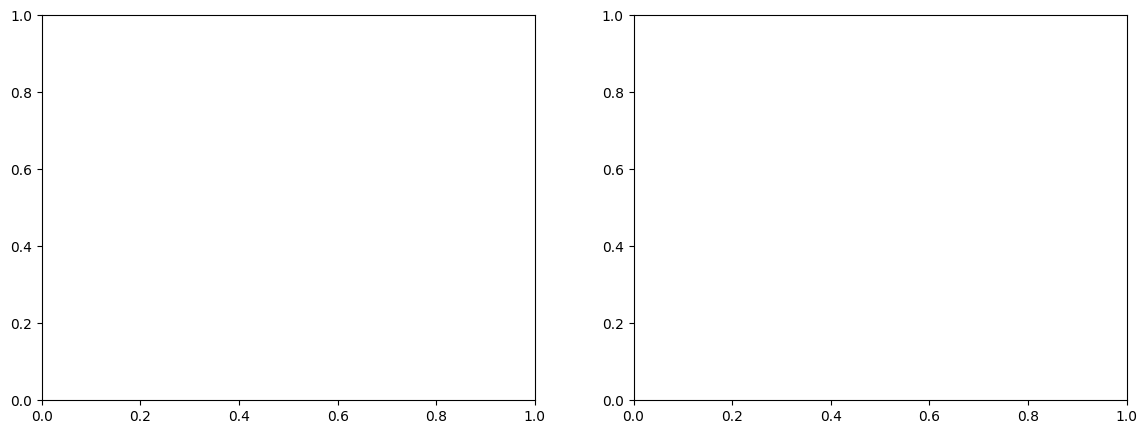

In [9]:
# Curvas de treino
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'],   label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_f1'], label='Train F1')
axes[1].plot(history['val_f1'],   label='Val F1')
axes[1].axhline(y=0.738, color='r', linestyle='--', label='Baseline (0.738)')
axes[1].set_title('F1-macro')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../models/curvas_treino.png', dpi=150)
plt.show()

## 7. Avaliação no Conjunto de Teste

In [ ]:
# Carregar o melhor modelo guardado
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

# Avaliar no teste
_, test_f1, test_preds, test_labels, test_probs = evaluate(
    model, test_loader, criterion, DEVICE
)

print('=' * 60)
print(f'F1-macro no TESTE: {test_f1:.4f}  (Baseline: 0.7380)')
diff = test_f1 - 0.738
print(f'Diferença face à baseline: {diff:+.4f}')
print('=' * 60)

print('\nClassification Report:')
print(classification_report(test_labels, test_preds,
                            target_names=CLASS_NAMES, digits=4, zero_division=0))

In [ ]:
# Matriz de Confusão
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5)
plt.title(f'Matriz de Confusão — {MODEL_NAME}\nF1-macro = {test_f1:.4f}')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'../models/{MODEL_NAME}_confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
# AUC-ROC (one-vs-rest)
from sklearn.preprocessing import label_binarize

test_labels_bin = label_binarize(test_labels, classes=list(range(NUM_CLASSES)))
auc_macro = roc_auc_score(test_labels_bin, test_probs, average='macro', multi_class='ovr')
print(f'AUC-ROC macro: {auc_macro:.4f}')

# AUC por classe
for i, cls in enumerate(CLASS_NAMES):
    auc_cls = roc_auc_score(test_labels_bin[:, i], test_probs[:, i])
    print(f'  {cls}: {auc_cls:.4f}')

## 8. Interpretabilidade — Grad-CAM

Grad-CAM gera mapas de calor que mostram quais regiões da imagem o modelo usou para tomar a decisão de classificação.

In [ ]:
class GradCAM:
    """Implementação de Grad-CAM para qualquer modelo PyTorch"""
    
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Hooks para capturar activações e gradientes
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_backward_hook(self._save_gradient)
    
    def _save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate(self, img_tensor, class_idx=None):
        self.model.eval()
        img_tensor = img_tensor.unsqueeze(0).to(DEVICE)
        
        # Forward pass
        output = self.model(img_tensor)
        
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        
        # Backward pass para a classe alvo
        self.model.zero_grad()
        output[0, class_idx].backward()
        
        # Calcular pesos (média global dos gradientes)
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        
        # Combinação linear ponderada das activações
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)  # Só activações positivas
        
        # Normalizar e redimensionar para o tamanho da imagem
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
        
        pred_class = CLASS_NAMES[class_idx]
        prob = F.softmax(output, dim=1)[0, class_idx].item()
        
        return cam, pred_class, prob


def overlay_heatmap(img_tensor, cam):
    """Sobrepõe o heatmap Grad-CAM na imagem original"""
    # Desnormalizar imagem
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)
    img_uint8 = (img_np * 255).astype(np.uint8)
    
    # Heatmap colorido
    heatmap = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    # Sobreposição
    overlay = (0.6 * img_uint8 + 0.4 * heatmap).astype(np.uint8)
    return img_np, heatmap / 255.0, overlay / 255.0


print('Grad-CAM definido.')

In [ ]:
# Identificar a última camada convolucional do EfficientNetV2-S
# No timm, normalmente é model.conv_head ou model.features[-1]
try:
    target_layer = model.conv_head
except AttributeError:
    # Fallback — última camada do bloco features
    target_layer = list(model.children())[-3]

print(f'Camada alvo para Grad-CAM: {target_layer.__class__.__name__}')

gradcam = GradCAM(model, target_layer)

In [ ]:
# Gerar Grad-CAM para um exemplo de cada classe
fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(12, NUM_CLASSES * 3.5))
col_titles = ['Original', 'Heatmap', 'Sobreposição']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=12, fontweight='bold')

for row, cls in enumerate(CLASS_NAMES):
    # Pegar num exemplo correcto desta classe do conjunto de teste
    cls_idx = CLASS_NAMES.index(cls)
    cls_samples = [(img, lbl) for img, lbl in zip(
        [s[0] for s in test_ds.samples],
        [s[1] for s in test_ds.samples]
    ) if lbl == cls_idx]
    
    # Escolher o primeiro exemplo
    img_path, true_label = cls_samples[0]
    img_tensor, _ = test_ds[test_ds.samples.index((img_path, true_label))]
    
    # Gerar Grad-CAM
    cam, pred_class, prob = gradcam.generate(img_tensor, class_idx=cls_idx)
    original, heatmap, overlay = overlay_heatmap(img_tensor, cam)
    
    # Plotar
    axes[row, 0].imshow(original)
    axes[row, 0].set_ylabel(f'{cls}\n(Real)', fontsize=9)
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(heatmap)
    axes[row, 1].axis('off')
    
    axes[row, 2].imshow(overlay)
    axes[row, 2].set_xlabel(f'Pred: {pred_class} ({prob:.2%})', fontsize=9)
    axes[row, 2].axis('off')

plt.suptitle(f'Grad-CAM — {MODEL_NAME}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/gradcam_resultados.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grad-CAM guardado em ../models/gradcam_resultados.png')

## 9. Resumo Final

In [ ]:
print('=' * 60)
print('RESUMO FINAL')
print('=' * 60)
print(f'Modelo:          {MODEL_NAME}')
print(f'Resolução:       {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch size:      {BATCH_SIZE}')
print(f'F1-macro Teste:  {test_f1:.4f}')
print(f'AUC-ROC macro:   {auc_macro:.4f}')
print(f'Baseline:        0.7380')
print(f'Diferença:       {test_f1 - 0.738:+.4f}')
print('=' * 60)
print('\nFicheiros gerados em ../models/:')
for f in os.listdir('../models/'):
    print(f'  {f}')